In [17]:
import multiGP_functions as mf
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fmin_l_bfgs_b, curve_fit
from spleaf import cov, term
import scipy.io as sp
import emcee
import pandas as pd

In [ ]:
t_full, y_full, yerr_full, series_index = mf.load_and_norm_data("../../data/Solar_Data", "Sun",normalise=False, inject_planet=False, planet_params=(3, 0.01, 0.01))

t_full = t_full - np.min(t_full)

# rv_planet = mf.planet_injection(t_full[series_index[0]], 3.0, 0.01, 0.01)

plt.figure()
plt.errorbar(t_full[series_index[0]], y_full[series_index[0]], yerr_full[series_index[0]], fmt=".", color="blue", label="RV")
# plt.plot(t_full[series_index[0]], rv_planet,  color="red", label="Planet")
plt.legend()

plt.figure()
plt.errorbar(t_full[series_index[1]], y_full[series_index[1]], yerr_full[series_index[1]], fmt=".", color="blue", label="RV")
plt.legend()

In [3]:
class MultiSeriesKernel(term.MultiSeriesKernel):
  def _grad_param(self, grad_dU=None, grad_dV=None):
    if grad_dU is not None or grad_dV is not None:
      raise NotImplementedError()
    return super()._grad_param()

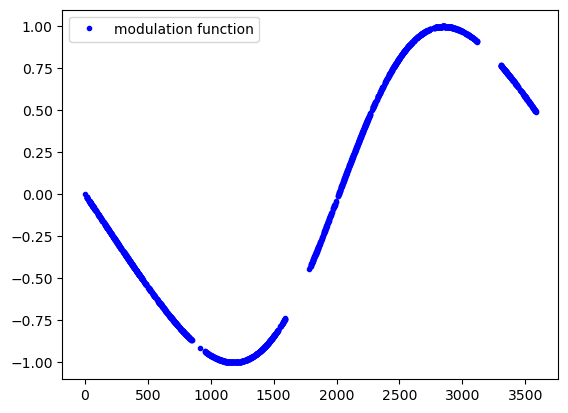

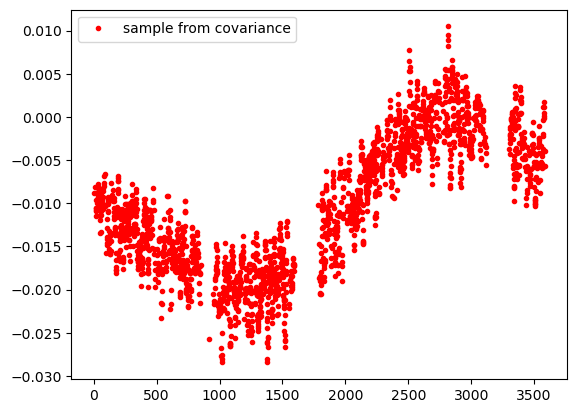

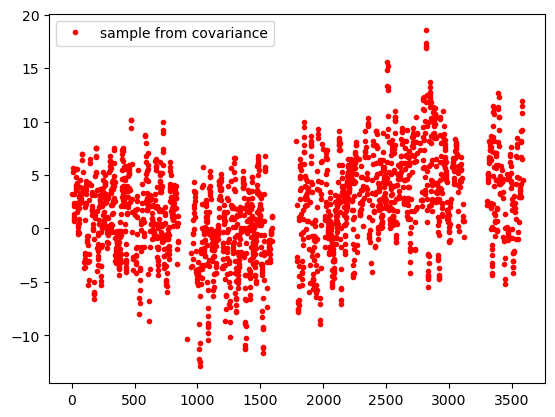

In [6]:
stds = [np.std(y_full[series_index[0]]), np.std(y_full[series_index[1]])]
# sig = np.var(y_full[series_index[0]]) 
sig = 1.0

prot = 27.0
Q = 1.2

rvjit = 0.1*stds[0]
rhkjit = 0.1*stds[1]

pcyc, phi, k = 4030.0, -np.pi, 0.28


C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
  rot = MultiSeriesKernel(term.SHOKernel(sig,prot, Q), series_index, 
        np.array([stds[0], stds[1]]), 
        np.array([stds[0], 0.0])
    ),
  )

fc = mf.alpha(t_full[series_index[0]], pcyc, phi, k)

plt.figure()
plt.plot(t_full[series_index[0]],fc, ".", color="blue", label="modulation function")
plt.legend()

drawn_sample = C.sample()

plt.figure()
plt.plot(t_full[series_index[0]], drawn_sample[series_index[0]]+0.01*fc-0.01, ".", color="red", label="sample from covariance")
plt.legend()
plt.figure()
plt.plot(t_full[series_index[1]], drawn_sample[series_index[1]]+3*fc+2, ".", color="red", label="sample from covariance")
plt.legend()


In [ ]:
np.random.seed(42)

data_rhk = pd.read_csv(f"../../data/Solar_Data/Analyse_summary.csv")
data_rhk = data_rhk[data_rhk["flag"] != 1]

tt = np.array(data_rhk["jdb"])
tref = np.min(tt)
tt = tt - tref
T = [tt,tt]

gamma_0 = 1.9
gamma_1 = 1.5
delta_0 = - 0.5
delta_1 = 1.2

fake_fc = mf.alpha(tt, 8000, np.pi, 0.28)
sample = C.sample()

fake_rv = sample[series_index[0]] 
print(fake_rv)
# fake_rv += gamma_0*fake_fc + delta_0 
fake_rv = fake_rv + mf.planet_injection(tt, 100.0, 0.5, 0.5)

fake_rhk = sample[series_index[1]]
# fake_rhk += gamma_1*fake_fc + delta_1

rv_mean = np.mean(fake_rv)
rv_std  = np.std(fake_rv)
rv_norm = (fake_rv - rv_mean) / rv_std

rhk_mean = np.mean(fake_rhk)
rhk_std  = np.std(fake_rhk)
rhk_norm = (fake_rhk - rhk_mean) / rhk_std

# # ERROR normalization using SAME scaling as parent data
erv_norm     = np.ones_like(fake_rv) * 0.3 / rv_std
rhk_err_norm = np.ones_like(fake_rhk) * 0.3 / rhk_std

Y = [rv_norm + gamma_0*fake_fc + delta_0, rhk_norm + gamma_1*fake_fc + delta_1]
Yerr = [erv_norm,rhk_err_norm]

t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)


plt.figure()
plt.errorbar(tt, y_full[series_index[0]], yerr=yerr_full[series_index[0]], fmt=".", color="green", label="fake RV with modulation and planet")
plt.plot(tt, mf.planet_injection(tt, 100.0, 0.5, 0.5)/rv_std, color="red", label="Planet")
plt.legend()
plt.figure()
plt.errorbar(tt, y_full[series_index[1]], yerr=yerr_full[series_index[1]], fmt=".", color="blue", label="fake RHK with modulation")
plt.legend()


In [7]:
rvjit_max = 5*stds[0]
rhkjit_max = 5*stds[1]

prot_min = 20.0
prot_max = 32.0
Q_min = 0.9
Q_max = 3.0

alpha_0_max = 10*stds[0]
alpha_1_max = 5*stds[1]
beta_0_max  = 10*stds[0]

pcyc_min = 3000.0
pcyc_max = 6500.0

gamma_0_max = 5*stds[0]
gamma_1_max = 5*stds[1]

planet_p_min = 3.0
planet_p_max = 7.0
planet_A_min = 0.001
planet_A_max = 0.1
planet_B_min = 0.001
planet_B_max = 0.1

bounds_list = [
    (0.0, rvjit_max),                     # rv_jit.sig
    (0.0, rhkjit_max),                     # rhk_jit.sig
    
    (prot_min, prot_max),                 # rot.P0 (period)
    (Q_min, Q_max),                      # rot.Q (quality factor)
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-beta_0_max, beta_0_max),         # rot.beta_0      # rot.beta_1
    (pcyc_min, pcyc_max),
    (0,np.pi*2),
    (-0.4,0.4),  # k
    # (0.01,0.99), 
    (0.0, gamma_0_max),         # rot.gamma_0
    (0.0, gamma_1_max),         # rot.gamma_1
    (-1, 1),         # delta_0 (offset for series 0)
    (-20,20),    
    # (planet_p_min, planet_p_max),                         # P_planet
    # (planet_A_min, planet_A_max),                          # A_planet
    # (planet_B_min, planet_B_max),                          # B_planet

]

print(rvjit_max)
print(rhkjit_max)
print(alpha_0_max)
print(bounds_list)

0.014496332978140545
19.700714665869167
0.02899266595628109
[(0.0, np.float64(0.014496332978140545)), (0.0, np.float64(19.700714665869167)), (20.0, 32.0), (0.9, 3.0), (0, np.float64(0.02899266595628109)), (np.float64(-19.700714665869167), np.float64(19.700714665869167)), (np.float64(-0.02899266595628109), np.float64(0.02899266595628109)), (3000.0, 6500.0), (0, 6.283185307179586), (-0.4, 0.4), (0.0, np.float64(0.014496332978140545)), (0.0, np.float64(19.700714665869167)), (-1, 1), (-20, 20)]


In [ ]:
map_sample = np.load("../../../non_stationary_gp/nskernel/data/sun_map_sample.npy")

params_inds = [k for k, key in enumerate(C.param) if key != 'rot.sig' and key != "rot.beta_1"]  
params = [C.param[k] for k in params_inds]

x0 = C.get_param(params)
x0 = np.append(x0,[6000, map_sample[3], map_sample[4], 0.01, 1.6, -0.01, 5.0])   # Added initial guesses for new parameters (delta_0, delta_1, planet parameters)


negloglike = mf.negloglike

result = fmin_l_bfgs_b(negloglike, x0, args=(y_full, C, params, params_inds, t_full, series_index, 1.0, False), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])


print(params)
print(xbest)
# print(negloglike(xbest, y_full, C, params, params_inds, t_full, series_index, 1.0, True)[0])

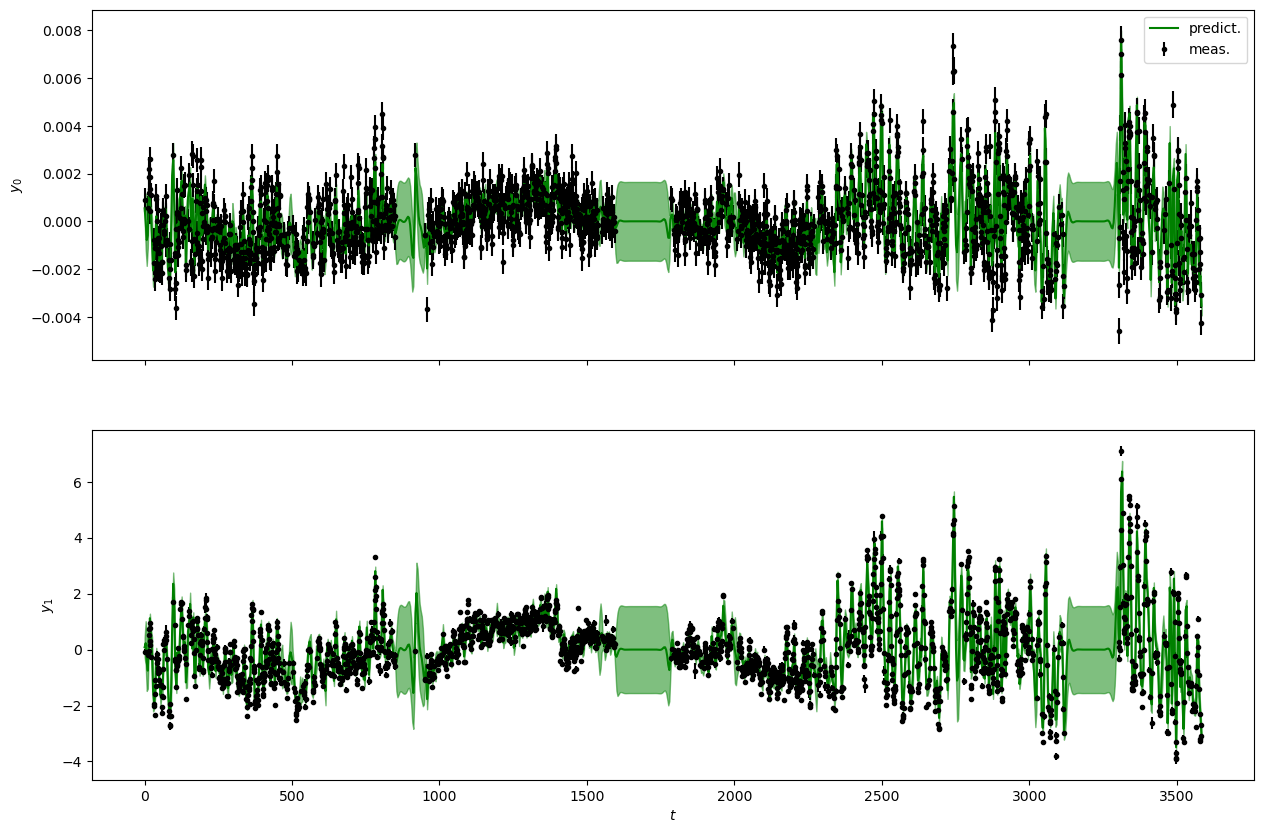

In [9]:
tsmooth, mu = mf.plot_fit(t_full, y_full, yerr_full, C, xbest, series_index, 1.0, output_name='fit_plot.png', return_residuals=False, inject_planet=False)

In [10]:
def log_prior(theta):
    # unpack theta (added delta_0, delta_1 as final two entries)
    rv_jit, rhk_jit, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, pcyc, phi, k, gamma_0, gamma_1, delta_0, delta_1 = theta
    # rv_jit, rhk_jit, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, pcyc, phi, k, gamma_0, gamma_1, delta_0, delta_1, planet_p, planet_A, planet_B = theta
    phi = phi % (2*np.pi)
    # if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and pcyc_min < pcyc < pcyc_max and 0 < phi < np.pi*2 and -0.4 < k < 0.4 and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and 0.0 < gamma_0 < gamma_0_max and 0.0 < gamma_1 < gamma_1_max and -1 < delta_0 < 1 and -20 < delta_1 < 20 and planet_p_min < planet_p < planet_p_max and planet_A_min < planet_A < planet_A_max and planet_B_min < planet_B < planet_B_max:
    if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and pcyc_min < pcyc < pcyc_max and 0 < phi < np.pi*2 and -0.4 < k < 0.4 and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and 0.0 < gamma_0 < gamma_0_max and 0.0 < gamma_1 < gamma_1_max and -1 < delta_0 < 1 and -20 < delta_1 < 20:
        return 0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C, params, params_inds, t_full, series_index, 1.0, False)[0]

x0 = xbest.copy()

# x0 = map_sample[[0,1,6,7,8,9,10]]
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-4 * np.random.randn(ndim*3, ndim)
# pos = x0 
nwalkers, ndim = pos.shape


sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 3000, progress=True);


[ 0.00000000e+00  3.78786119e-01  2.64448357e+01  9.00000000e-01
  1.48682598e-03  1.55512204e+00  3.01897006e-03  5.99892789e+03
  3.55649605e+00  3.81202085e-01  4.30716536e-03  6.38489187e+00
 -3.17755496e-02  4.70057378e+00]
-inf


  0%|          | 0/3000 [00:00<?, ?it/s]/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 3000/3000 [05:18<00:00,  9.43it/s]


['rv_jit.sig', 'rhk_jit.sig', 'rot.P0', 'rot.Q', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0', 'pcyc', 'phi', 'k', 'gamma_0', 'gamma_1', 'delta_0', 'delta_1']


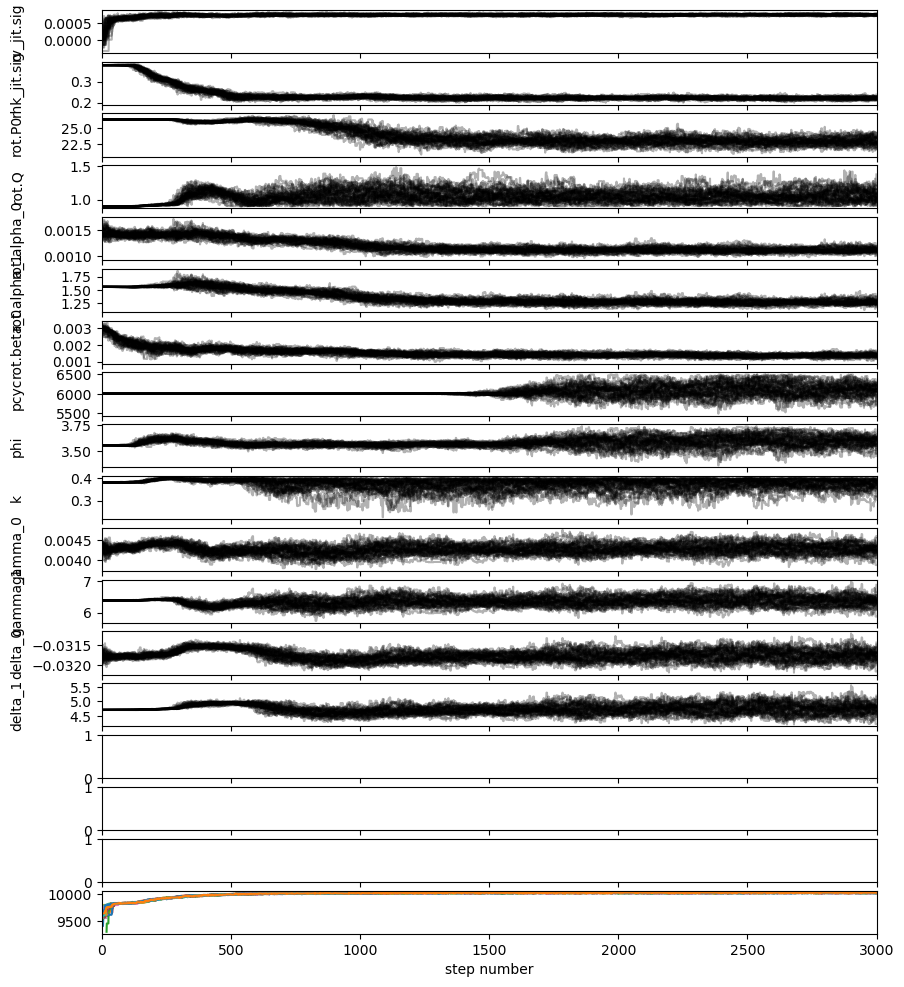

In [11]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(len(params) + 11, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()

# labels = params + ['pcyc','phi','k','gamma_0', 'gamma_1', 'delta_0', 'delta_1', 'planet_p', 'planet_A', 'planet_B']
labels = params + ['pcyc','phi','k','gamma_0', 'gamma_1', 'delta_0', 'delta_1']
print(labels)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

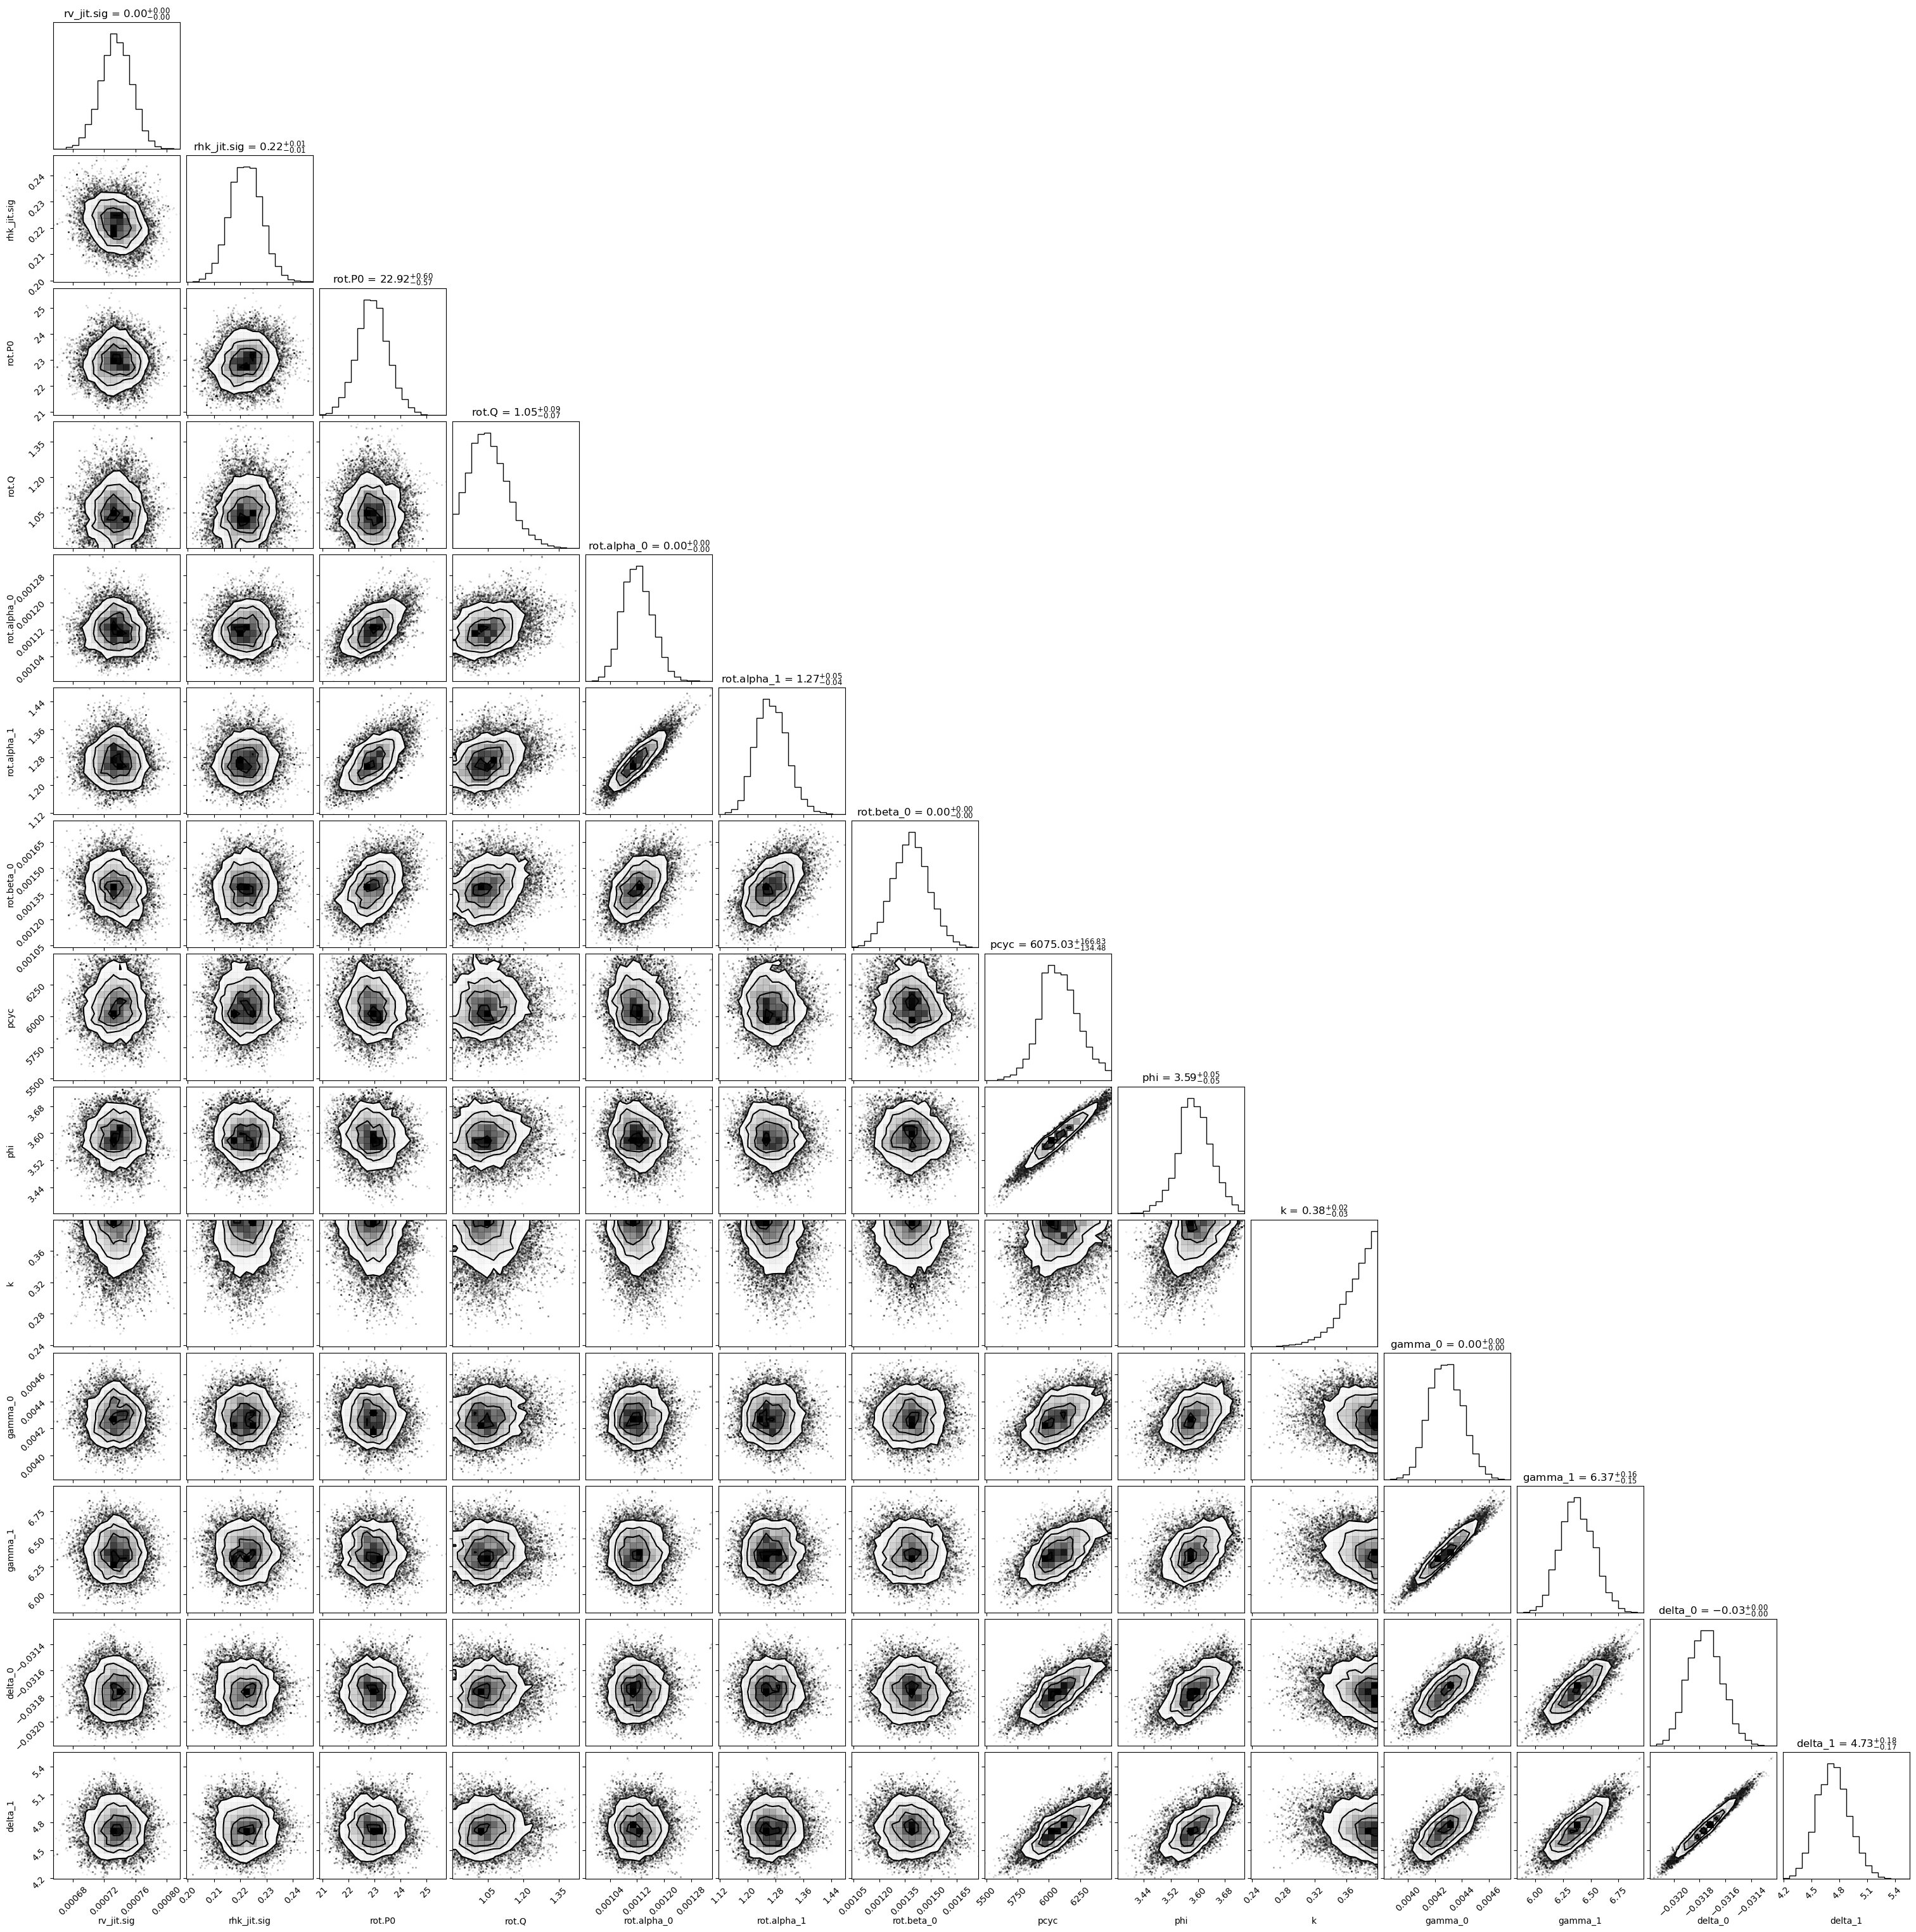

In [14]:
import corner

flat_samples = sampler.get_chain(discard=1500, thin=1, flat=True)

# true_vals = [0.0, 0.0, prot, Q, stds[0], stds[1], stds[0], 8000, np.pi, 0.28, gamma_0, gamma_1, delta_0, delta_1, 100.0, 0.5, 0.5]

fig = corner.corner(
    flat_samples, labels=labels, show_titles=True
);


MAP index (in flattened, post-burn chain): 42083
MAP log-posterior: 10029.924315777746
MAP sample (theta): [ 7.35475637e-04  2.26415694e-01  2.27979298e+01  1.05203318e+00
  1.09514805e-03  1.22929928e+00  1.35404405e-03  6.07775128e+03
  3.60145719e+00  3.93933514e-01  4.22075252e-03  6.28036591e+00
 -3.18344325e-02  4.63512048e+00]


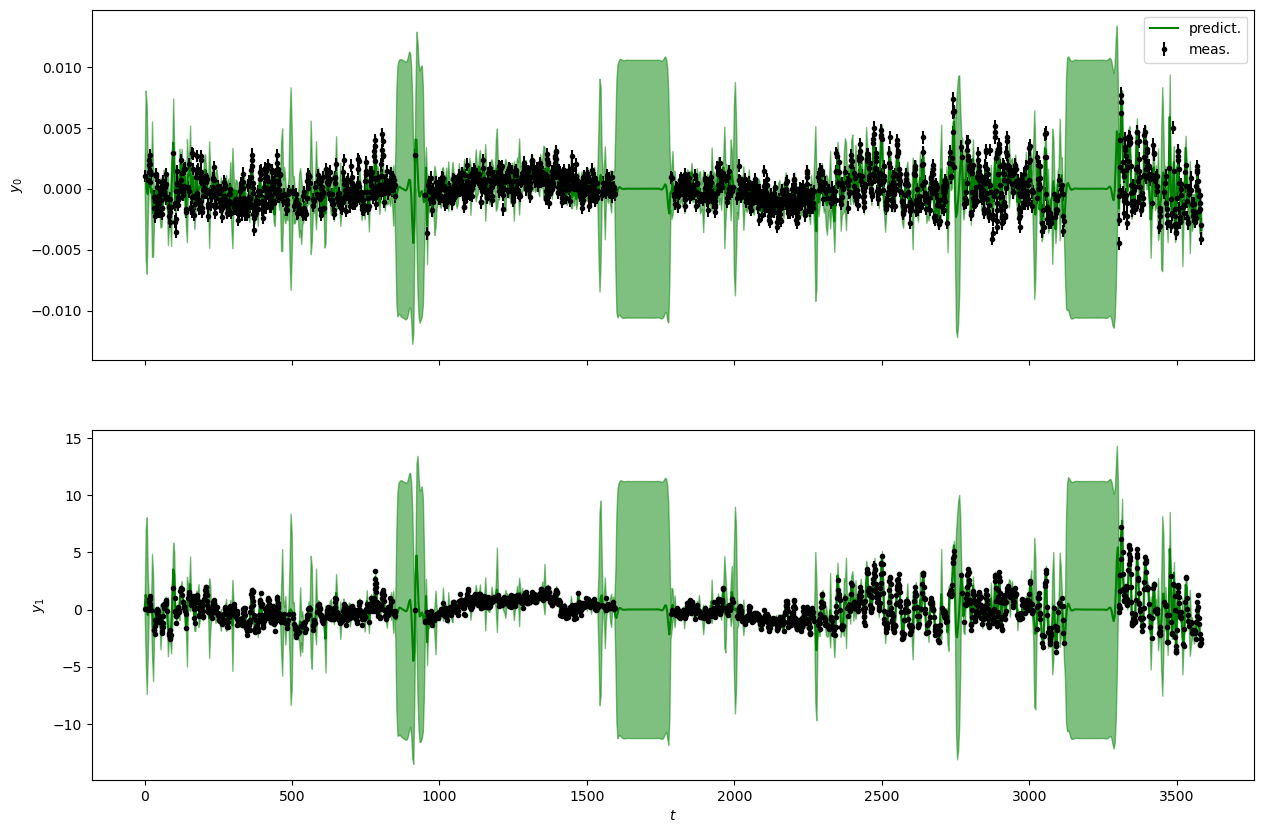

In [15]:
burn = 1500   
thin = 1

flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)   # shape (n_samples, ndim)
flat_logp    = sampler.get_log_prob(discard=burn, thin=thin, flat=True) # shape (n_samples,)

finite_mask = np.isfinite(flat_logp)
flat_samples = flat_samples[finite_mask]
flat_logp    = flat_logp[finite_mask]

map_idx = np.argmax(flat_logp)
map_sample = flat_samples[map_idx]
map_logp = flat_logp[map_idx]

print("MAP index (in flattened, post-burn chain):", map_idx)
print("MAP log-posterior:", map_logp)
print("MAP sample (theta):", map_sample)

np.save("sun_map_sample.npy", map_sample)

C.set_param(map_sample[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])
C.set_param([np.var(y_full)], ['rot.sig'])

tsmooth, mu, res_rv, res_rhk = mf.plot_fit(t_full, y_full, yerr_full, C, map_sample, series_index,output_name='fit_plot.png', return_residuals=True, inject_planet=False)

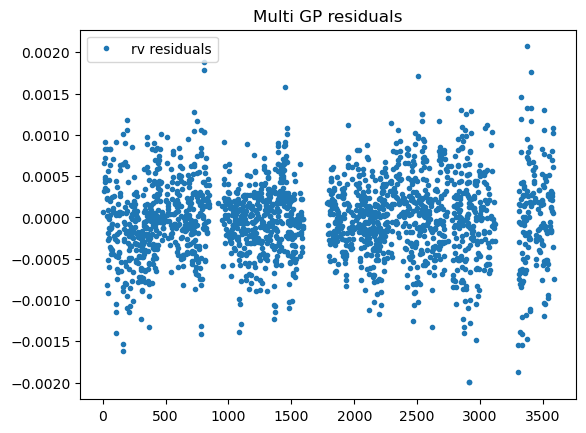

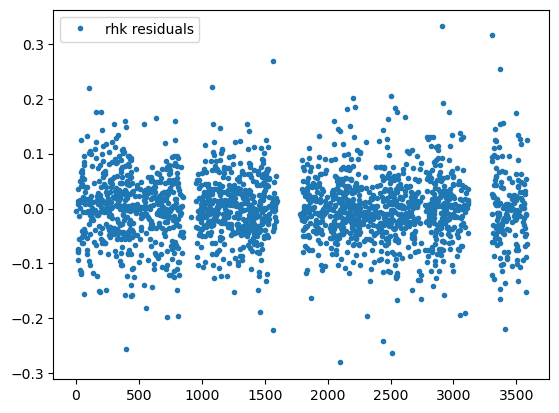

In [22]:
plt.figure()
plt.title("Multi GP residuals")
plt.plot(t_full[series_index[0]], res_rv, ".", label='rv residuals')
plt.legend()
plt.figure()
plt.plot(t_full[series_index[1]], res_rhk, ".", label='rhk residuals')
# plt.ylim(-1.5,1.5)
plt.legend()
plt.show()